# Credit card fraud: exploratory analysis

What the data looks like, what carries signal, and what the pipeline decided to do about it.

Everything here calls into `fraud_pipeline.eda`, `fraud_pipeline.plots` and
`fraud_pipeline.feature_selection`, the same code the `fraud eda` command runs. Nothing is
reimplemented in a cell, because a number computed in a notebook that disagrees with the number
computed in the pipeline is the worst outcome available.

**The training split only.** The test split is never opened, here or anywhere else before the
evaluation stage. Choosing features by looking at test data would make every metric this project
reports meaningless, and the config refuses to allow it.

In [1]:
import pandas as pd
from IPython.display import Image, display

from fraud_pipeline import eda, feature_selection, plots
from fraud_pipeline.config import load_config
from fraud_pipeline.splits import load_split

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 160)

config = load_config()
train = load_split(config, config.eda.analysis_split)
validation = load_split(config, config.eda.drift_split)


def show(name):
    """Display one of the generated figures inline."""
    display(Image(filename=str(config.paths.figures_dir() / name)))


print(f"train      {train.shape[0]:>7,} rows, {train['Class'].sum():>3} fraud ({train['Class'].mean():.4%})")
print(f"validation {validation.shape[0]:>7,} rows, {validation['Class'].sum():>3} fraud ({validation['Class'].mean():.4%})")

train      198,608 rows, 366 fraud (0.1843%)
validation  42,558 rows,  55 fraud (0.1292%)


## 1. The class balance shapes every later decision

At this rate a model that predicts "normal" every single time is over 99.8 percent accurate and
catches nothing. That is why accuracy appears nowhere in this project.

Class
0    198242
1       366

fraud rate                0.18428%
always-normal accuracy    99.81572%
one fraud case is worth   0.27% of recall


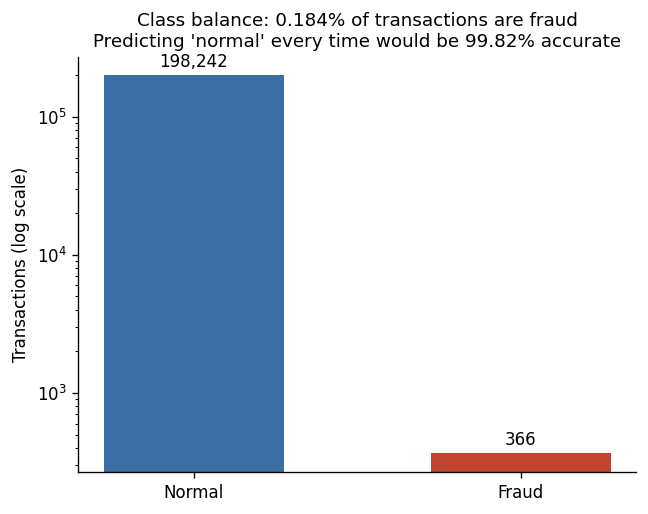

In [2]:
print(train["Class"].value_counts().to_string())
print(f"\nfraud rate                {train['Class'].mean():.5%}")
print(f"always-normal accuracy    {1 - train['Class'].mean():.5%}")
print(f"one fraud case is worth   {1 / train['Class'].sum():.2%} of recall")

plots.plot_class_balance(train, config)
show("01_class_balance.png")

## 2. Fraud follows the clock

This is the finding that changed how the split level fraud rates should be read.

Fraud rate over the two days looks erratic, with two spikes about 24 hours apart. Folding the
timeline onto a 24 hour clock explains it: fraud concentrates in the small hours, exactly when
transaction volume is at its lowest.

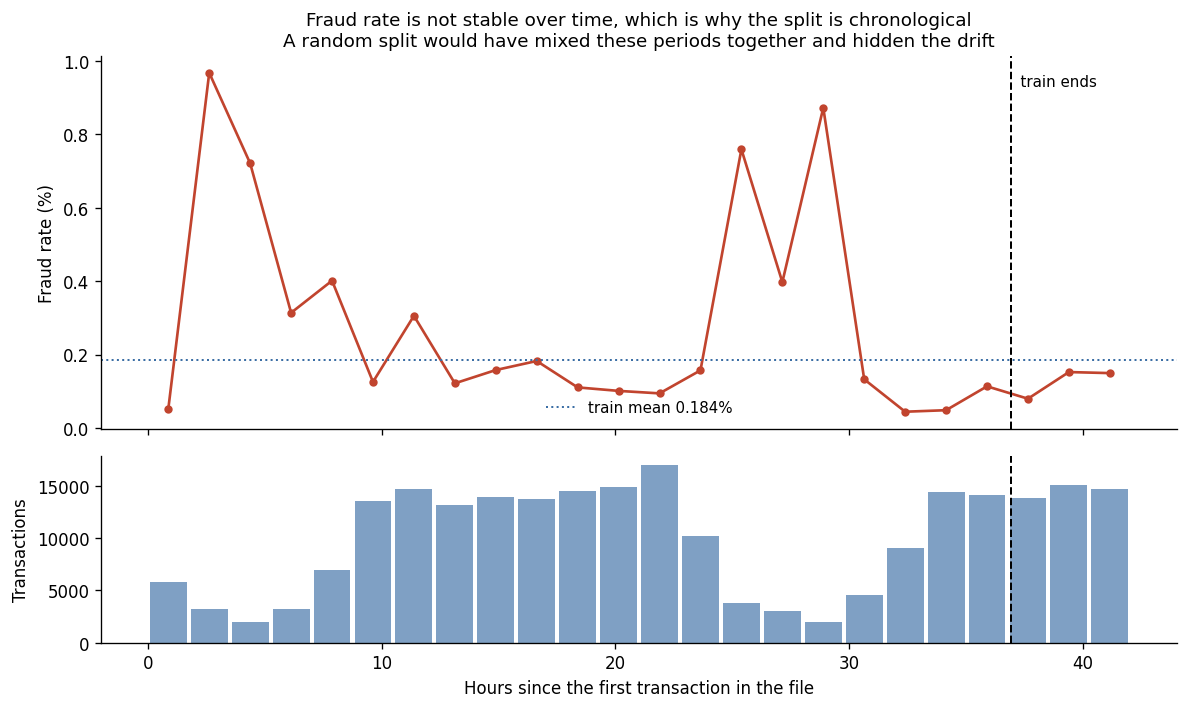

In [3]:
plots.plot_fraud_rate_over_time(train, validation, config)
show("02_fraud_rate_over_time.png")

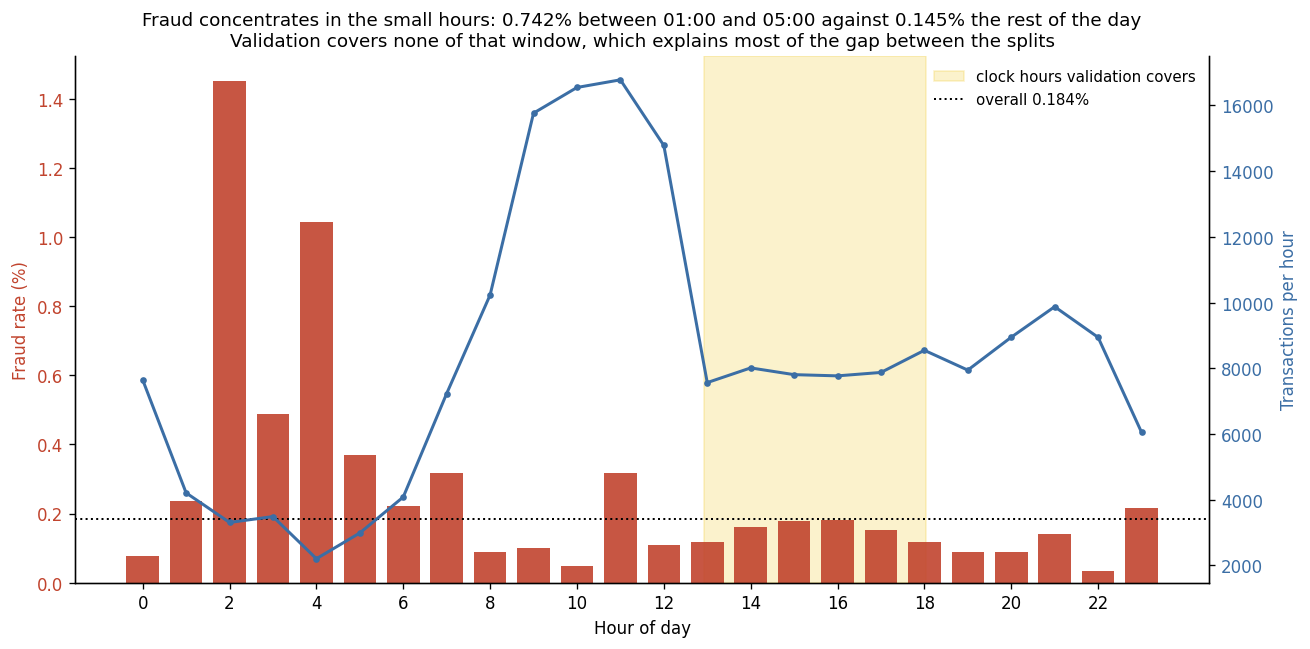

In [4]:
plots.plot_fraud_by_hour(train, validation, config)
show("07_fraud_by_hour.png")

In [5]:
clock = (train["Time"] / 3600.0) % 24
night = train[clock.between(1, 5)]["Class"].mean()
rest = train[~clock.between(1, 5)]["Class"].mean()

print(f"01:00 to 05:00   {night:.4%}")
print(f"all other hours  {rest:.4%}")
print(f"ratio            {night / rest:.2f}x\n")

window = (validation["Time"] / 3600.0) % 24
matched = train[clock.between(window.min(), window.max())]["Class"].mean()
print(f"train over validation's clock window ({window.min():.2f} to {window.max():.2f}): {matched:.4%}")
print(f"validation itself:                                    {validation['Class'].mean():.4%}")
print("\nMost of the gap between the splits is which hours they contain, not drift.")

01:00 to 05:00   0.7420%
all other hours  0.1446%
ratio            5.13x

train over validation's clock window (12.92 to 18.03): 0.1556%
validation itself:                                    0.1292%

Most of the gap between the splits is which hours they contain, not drift.


## 3. Per feature statistics

Six measures per feature, and they are not redundant:

| Measure | What it asks |
| --- | --- |
| `auc` | does fraud sit consistently high or low on this feature |
| `ks` | do the two distributions differ **in any way at all** |
| `abs_corr` | linear association with the target |
| `mutual_info` | non linear dependence |
| `psi` | how far the feature moved between train and validation |
| `range_coverage` | has the model seen values like the next period's before |

The gap between `auc` and `ks` is the interesting one. A feature can score near chance on AUC
while separating the classes clearly, if fraud clusters in the middle of its range rather than at
one end.

In [6]:
stats = eda.compute_feature_stats(train, validation, config)
stats

,feature,auc,ks,abs_corr,mutual_info,psi,range_coverage,dominant_share,n_unique,mean_fraud,mean_normal
0,V14,0.949201,0.842297,0.314582,0.029700,0.063716,1.000000,0.000388,193543,-7.003843,0.064668
1,V12,0.940488,0.782999,0.265490,0.027358,0.191129,1.000000,0.000388,193543,-6.795425,-0.058267
2,V4,0.937321,0.759578,0.141771,0.020066,0.104692,1.000000,0.000388,193543,4.684202,0.064440
3,V3,0.918816,0.705213,0.230077,0.018942,0.777037,1.000000,0.000388,193543,-7.368845,0.337427
4,V10,0.917241,0.815856,0.243456,0.027907,0.035696,1.000000,0.000388,193543,-6.113980,-0.001101
5,V11,0.915229,0.766632,0.163748,0.025296,0.327125,1.000000,0.000388,193543,4.084697,0.118916
6,V2,0.873526,0.653869,0.105323,0.014102,0.020823,1.000000,0.000388,193543,3.960445,-0.007795
7,V16,0.855594,0.715600,0.222214,0.023512,0.003887,0.999906,0.000388,193543,-4.566838,0.004099
8,V7,0.842183,0.694737,0.218576,0.017457,0.078394,0.999977,0.000388,193543,-6.176627,-0.037213
9,V9,0.835959,0.566771,0.102673,0.015698,0.048625,1.000000,0.000388,193543,-2.697450,0.011871


## 4. How much of that signal is real

Shuffle the target so any relationship is destroyed, then record the best score any feature still
reaches by chance. Repeat, and take a high quantile of those maxima.

Taking the **maximum across all features** on each shuffle is the point. Testing thirty features
and keeping the best is thirty chances to be fooled, and this accounts for that.

The result is the number that makes "weak" measured rather than guessed.

with the target shuffled 40 times, the best univariate AUC any of 30 features reached by chance averaged 0.5352 and peaked at 0.5567. The 95% quantile, 0.5486, is the AUC noise ceiling. The same procedure puts the KS ceiling at 0.0952, against a chance average of 0.0781.


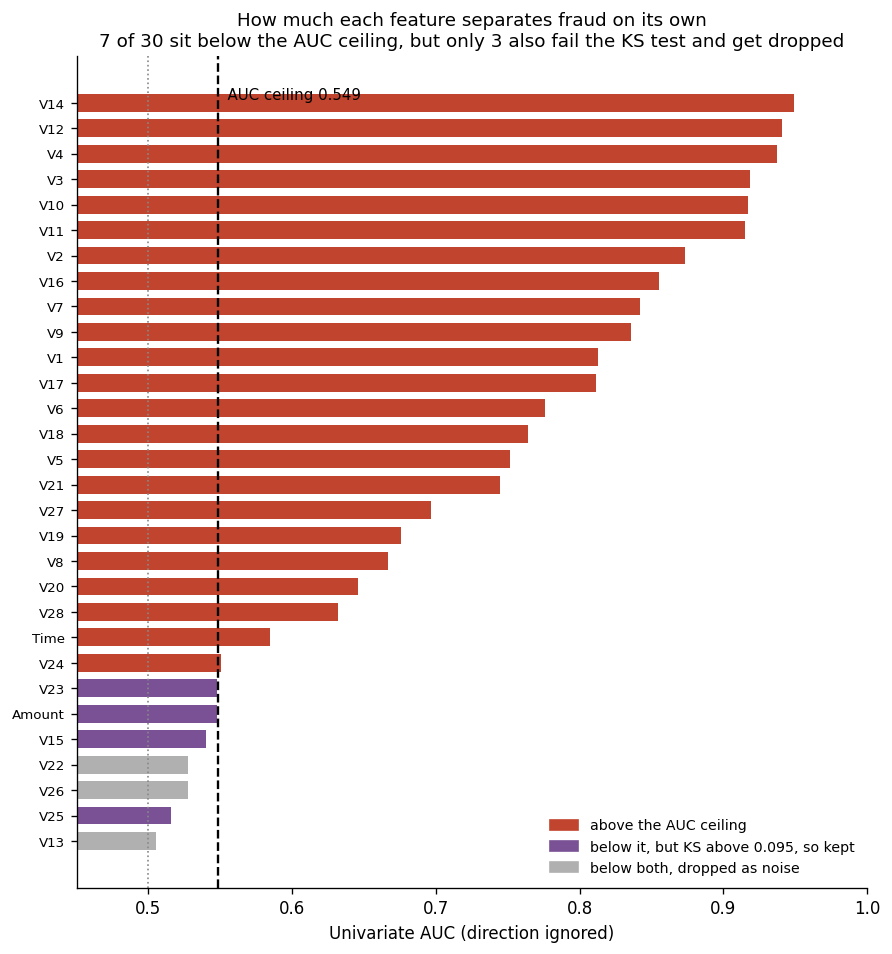

In [7]:
noise = eda.permutation_noise_ceiling(train, config)
print(noise.describe())

plots.plot_univariate_ranking(stats, noise, config)
show("04_univariate_ranking.png")

In [8]:
below = stats[stats["auc"] < noise.ceiling]
rescued = below[below["ks"] >= noise.ks_ceiling]

print(f"{len(below)} features fall below the AUC ceiling:")
print(below[["feature", "auc", "ks"]].to_string(index=False))
print(f"\nof those, {len(rescued)} still clear the KS ceiling and are kept:")
print(rescued[["feature", "auc", "ks"]].to_string(index=False))
print("\nAmount is the clearest case. An AUC only rule dropped it, and that was wrong.")

7 features fall below the AUC ceiling:
feature      auc       ks
    V23 0.548061 0.212124
 Amount 0.547856 0.260414
    V15 0.540125 0.102389
    V22 0.527779 0.080003
    V26 0.527387 0.086098
    V25 0.515453 0.104465
    V13 0.504965 0.082550

of those, 4 still clear the KS ceiling and are kept:
feature      auc       ks
    V23 0.548061 0.212124
 Amount 0.547856 0.260414
    V15 0.540125 0.102389
    V25 0.515453 0.104465

Amount is the clearest case. An AUC only rule dropped it, and that was wrong.


## 5. What the strongest features actually look like

A ranking says a feature separates the classes. This says how, which is what makes a later SHAP
explanation believable rather than something to take on trust.

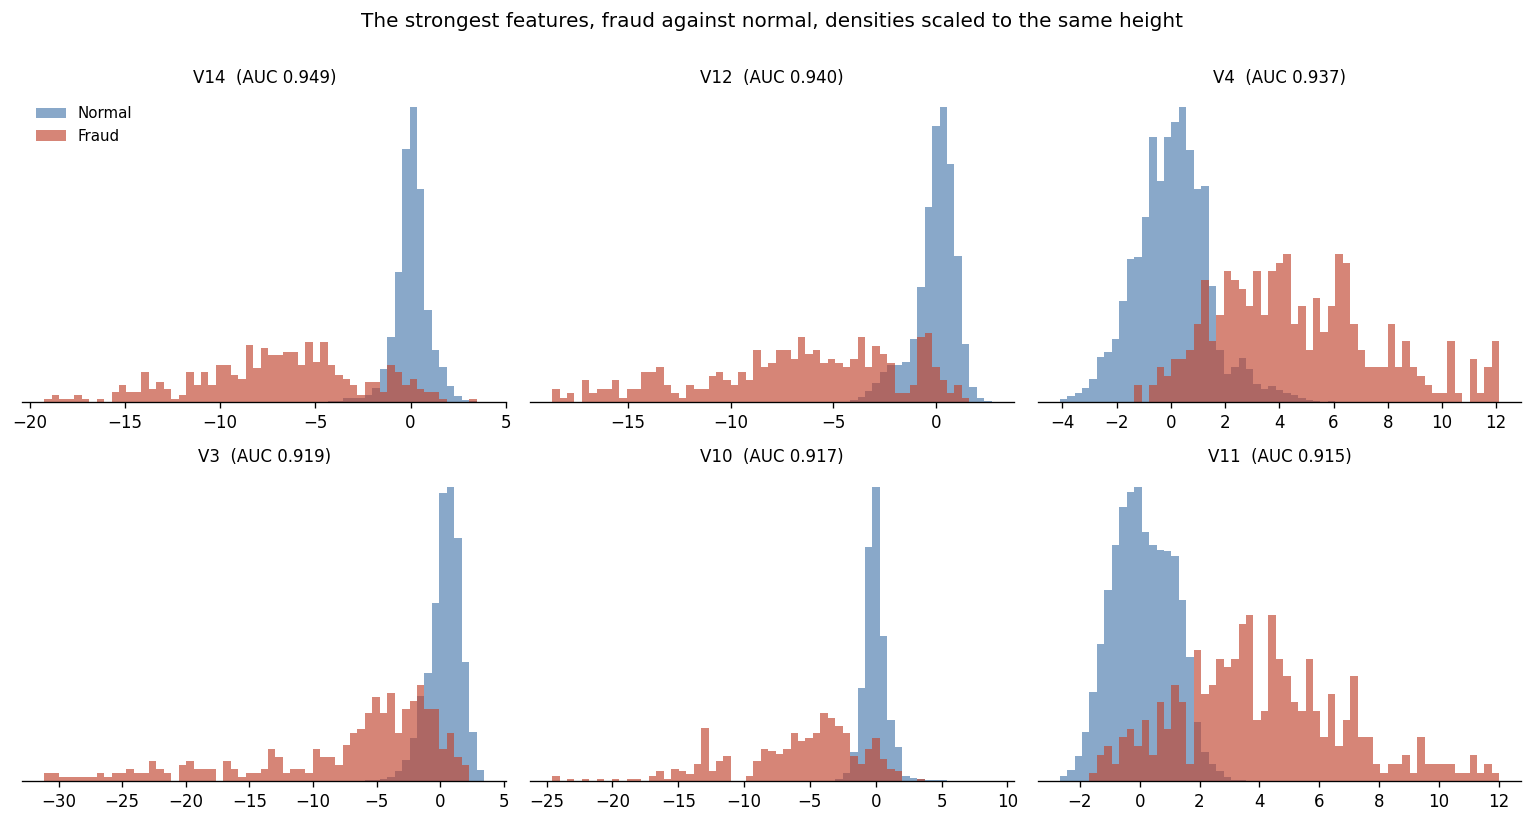

In [9]:
plots.plot_top_feature_distributions(train, stats, config)
show("05_top_feature_distributions.png")

## 6. Leakage and redundancy

Two questions to ask of any dataset before trusting a result.

Both come back empty here, and that is the expected answer rather than a lucky one: V1 to V28 are
principal components, so they are orthogonal to each other by construction and no original column
survives that could encode the answer.

The checks still run every time, because the IEEE CIS dataset has real named columns where a leak
is a genuine possibility.

features above the 0.99 leakage threshold: 0
exact duplicate columns: []


pairs above the 0.95 duplicate threshold: 0

most correlated pairs, whatever their strength:


feature_a feature_b  abs_corr
       V2    Amount  0.547765
      V20    Amount  0.403440
       V5    Amount  0.373988
       V7    Amount  0.371055
     Time        V3  0.346327
       V1    Amount  0.234959
       V3    Amount  0.209119
       V6    Amount  0.201866


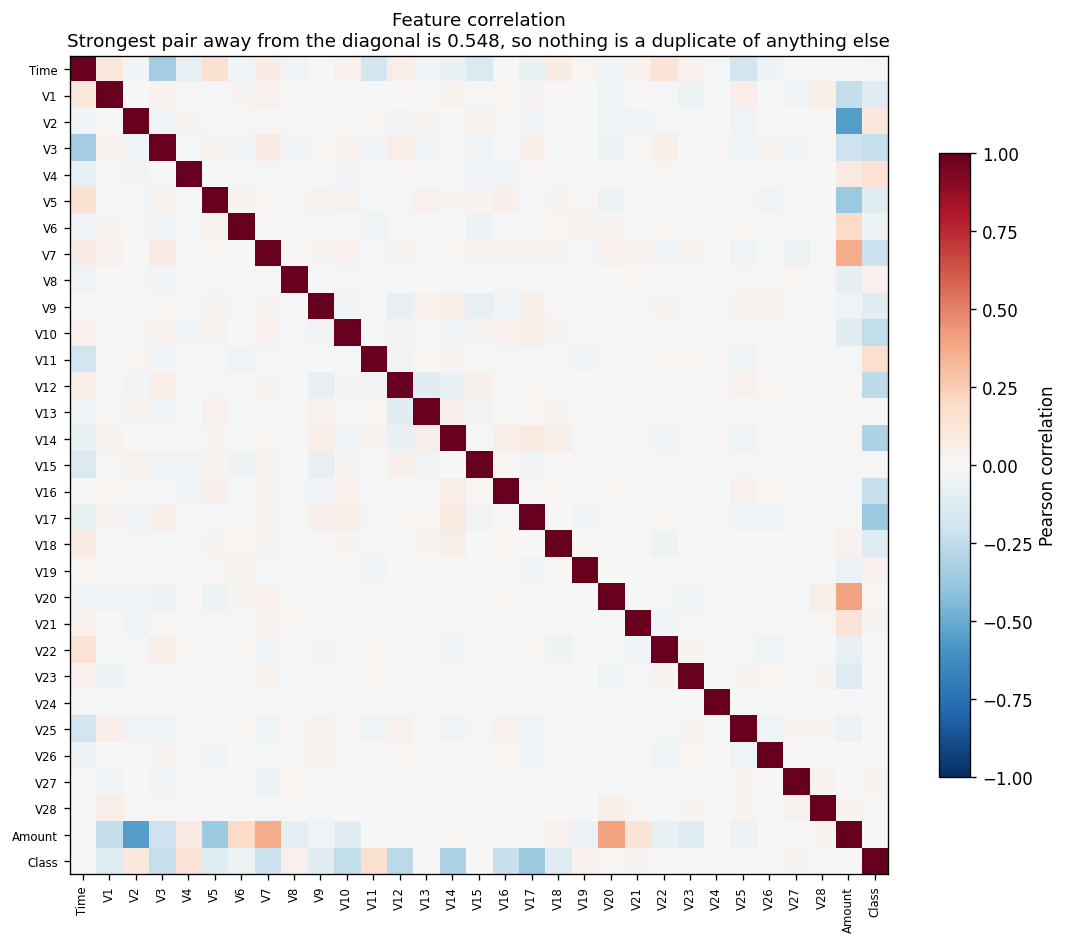

In [10]:
leaking = stats[stats["auc"] >= config.feature_selection.leakage_auc]
print(f"features above the {config.feature_selection.leakage_auc} leakage threshold: {len(leaking)}")
print(f"exact duplicate columns: {eda.exact_duplicate_columns(train, config)}")
print(f"pairs above the {config.feature_selection.duplicate_correlation} duplicate threshold: "
      f"{len(eda.correlated_pairs(train, config))}\n")

print("most correlated pairs, whatever their strength:")
print(eda.correlated_pairs(train, config, threshold=0.0).head(8).to_string(index=False))

plots.plot_correlation_heatmap(train, config)
show("03_correlation_heatmap.png")

## 7. Stability into the next period

Two different problems shown together on purpose.

**PSI** says the distribution moved, which a model can often survive. **Range coverage** says the
new values sit outside anything the model was fitted on, which it cannot.

Watch `Time`. It only ever increases, so every future value is beyond the training range.

feature      auc       psi  range_coverage
   Time 0.584348 12.433832        0.000023
     V1 0.812753  0.938302        1.000000
     V3 0.918816  0.777037        1.000000
    V28 0.632161  0.533985        1.000000
    V11 0.915229  0.327125        1.000000
    V25 0.515453  0.219815        1.000000
    V15 0.540125  0.206936        0.999977
    V12 0.940488  0.191129        1.000000

train Time               0 to    132,906
validation Time    132,906 to    151,320
The two windows do not overlap at all.


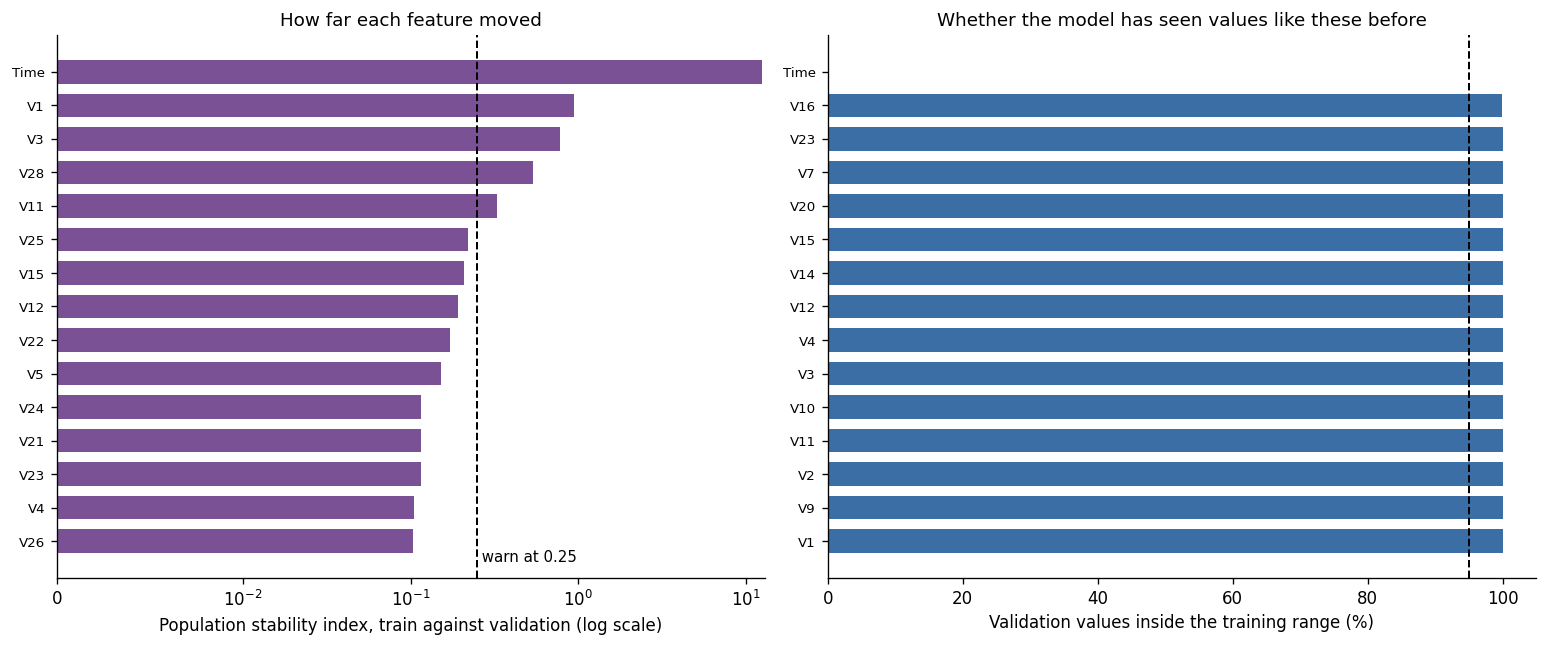

In [11]:
print(stats.nlargest(8, "psi")[["feature", "auc", "psi", "range_coverage"]].to_string(index=False))
print(f"\ntrain Time      {train['Time'].min():>10,.0f} to {train['Time'].max():>10,.0f}")
print(f"validation Time {validation['Time'].min():>10,.0f} to {validation['Time'].max():>10,.0f}")
print("The two windows do not overlap at all.")

plots.plot_stability(stats, config)
show("06_stability.png")

## 8. What the selection system decides

The same call the `fraud eda` command makes. Every drop carries its evidence, so nothing here is a
judgement that cannot be argued with.

Rules come in two tiers. **Tier 1 is correctness**: leakage, duplicates, constants, and features
that cannot generalise. **Tier 2 is judgement**: features with no measurable signal, which is
arguable because univariate screening cannot see interactions.

In [12]:
selection = feature_selection.select_features(
    stats,
    eda.correlated_pairs(train, config),
    noise,
    config,
    eda.exact_duplicate_columns(train, config),
)

print(f"feature sets: {selection.counts()}\n")
for decision in selection.decisions:
    if decision.dropped_by_tier is not None:
        print(f"  tier {decision.dropped_by_tier}  {decision.feature:<8} {decision.reasons[0]}")

feature sets: {'all': 30, 'safe': 29, 'selected': 26}

  tier 1  Time     only 0.00% of validation values fall inside the training range (limit 95%), so it cannot generalise
  tier 2  V22      no measurable signal: AUC 0.5278 below the 0.5486 ceiling and KS 0.0800 below the 0.0952 ceiling
  tier 2  V26      no measurable signal: AUC 0.5274 below the 0.5486 ceiling and KS 0.0861 below the 0.0952 ceiling
  tier 2  V13      no measurable signal: AUC 0.5050 below the 0.5486 ceiling and KS 0.0826 below the 0.0952 ceiling


## Ideas worth trying

Scratch space. Anything here that proves out gets moved into the module with a test.

- Does an interaction between two weak features beat either alone? Univariate screening cannot see
  this, and it is the known blind spot of the tier 2 rule.
- Do the features that drifted most (V1, V3, V28) also lose the most accuracy on validation?
- Is the amount distribution for fraud different by hour of day, or is it flat?